## Option B: PCA + SVM Classification

**Approach:** Apply Principal Component Analysis (PCA) directly on flattened RGB image pixels (EigenDogs/EigenCats), then train a Support Vector Machine (SVM) with an RBF kernel on the reduced feature space. Optimal C is selected via grid search with cross-validation.

**Libraries used:**
- numpy 1.x
- scikit-learn 1.x
- Pillow (PIL) 10.x
- matplotlib 3.x
- seaborn 0.x
- pandas 2.x

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# --- Data Loading ---
# Images resized to 128x128 RGB and flattened to 1D vectors (49,152 dims each).
# RGB retains color information which helps distinguish dogs from cats.

IMG_SIZE = (128, 128)
TRAIN_DIR = os.path.join('ecse-415-winter-2026-dog-vs-cat-classification', 'train', 'train')

classes = {'cats': 0, 'dogs': 1}
images = []
labels = []

for class_name, label in classes.items():
    class_dir = os.path.join(TRAIN_DIR, class_name)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        try:
            img = Image.open(fpath).convert('RGB').resize(IMG_SIZE)
            images.append(np.array(img).flatten())
            labels.append(label)
        except Exception:
            # Skip corrupt or unreadable files
            pass

X = np.array(images, dtype=np.float32)
y = np.array(labels)

print(f'Loaded {X.shape[0]} images, feature dim: {X.shape[1]}')
print(f'Cats: {(y == 0).sum()}, Dogs: {(y == 1).sum()}')

Loaded 20000 images, feature dim: 49152
Cats: 10021, Dogs: 9979


In [3]:
# --- 80/20 Stratified Train/Test Split ---

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Internal test samples: {X_test.shape[0]}')

Training samples: 16000
Internal test samples: 4000


Explained variance with 300 components: 0.895


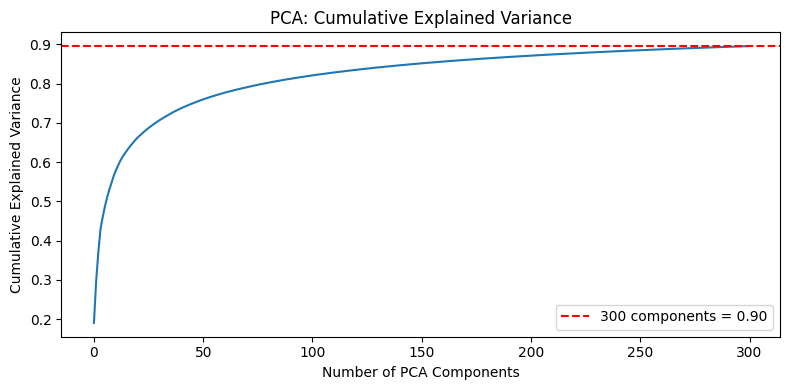

In [4]:
# --- Standardization + PCA ---
# Scaler and PCA are fit ONLY on training data to prevent data leakage.
# n_components=300 captures more variance from the higher-dimensional RGB input.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

N_COMPONENTS = 300
pca = PCA(n_components=N_COMPONENTS, svd_solver='randomized', random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)[-1]
print(f'Explained variance with {N_COMPONENTS} components: {cumulative_variance:.3f}')

# Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.axhline(y=cumulative_variance, color='r', linestyle='--',
            label=f'{N_COMPONENTS} components = {cumulative_variance:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# --- SVM Hyperparameter Tuning (Grid Search) ---
# Searches over C=[0.1, 1, 10, 100] with gamma='scale' using 3-fold cross-validation.
# n_jobs=-1 parallelizes across CV folds using all available CPU cores.
# probability=True is set upfront so the best estimator supports predict_proba.

param_grid = {'C': [0.1, 1, 10, 100]}
base_svm = SVC(kernel='rbf', gamma='scale', probability=True, random_state=42)

grid_search = GridSearchCV(
    base_svm, param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1
)
grid_search.fit(X_train_pca, y_train)

print(f'\nBest C: {grid_search.best_params_["C"]}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

# Show all C values and their mean CV accuracy
cv_results = grid_search.cv_results_
for c, mean_score in zip(param_grid['C'], cv_results['mean_test_score']):
    print(f'  C={c:<6} -> CV accuracy: {mean_score:.4f}')

best_svm = grid_search.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best C: 1
Best CV accuracy: 0.6663
  C=0.1    -> CV accuracy: 0.6308
  C=1      -> CV accuracy: 0.6663
  C=10     -> CV accuracy: 0.6629
  C=100    -> CV accuracy: 0.6549


Accuracy: 0.6855

              precision    recall  f1-score   support

         Cat       0.68      0.70      0.69      2004
         Dog       0.69      0.67      0.68      1996

    accuracy                           0.69      4000
   macro avg       0.69      0.69      0.69      4000
weighted avg       0.69      0.69      0.69      4000



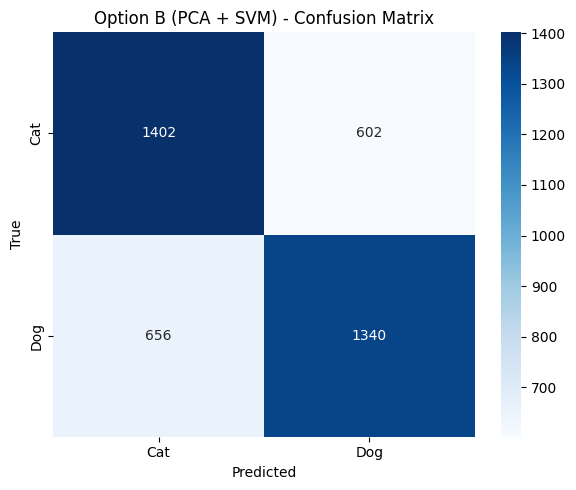

In [6]:
# --- Evaluation on Internal Test Split ---

y_pred = best_svm.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}\n')
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Option B (PCA + SVM) - Confusion Matrix')
plt.tight_layout()
plt.show()

In [7]:
# --- Kaggle Test Set Predictions ---
# Applies the same preprocessing pipeline (scaler + PCA) fitted on training data.
# Outputs probabilities (0-1) where values closer to 1 indicate Dog.

TEST_DIR = os.path.join('ecse-415-winter-2026-dog-vs-cat-classification', 'test', 'test')

test_ids = []
test_images = []

for fname in os.listdir(TEST_DIR):
    fpath = os.path.join(TEST_DIR, fname)
    try:
        img = Image.open(fpath).convert('RGB').resize(IMG_SIZE)
        test_images.append(np.array(img).flatten())
        test_ids.append(int(os.path.splitext(fname)[0]))
    except Exception:
        pass

X_kaggle = np.array(test_images, dtype=np.float32)
X_kaggle_scaled = scaler.transform(X_kaggle)
X_kaggle_pca = pca.transform(X_kaggle_scaled)

# predict_proba returns [P(cat), P(dog)]; column 1 = P(dog)
kaggle_probs = best_svm.predict_proba(X_kaggle_pca)[:, 1]

submission = pd.DataFrame({'id': test_ids, 'label': kaggle_probs})
submission = submission.sort_values('id').reset_index(drop=True)
submission.to_csv('option_b_submission.csv', index=False)

print(f'Saved {len(submission)} predictions to option_b_submission.csv')
print(submission.head())

Saved 5000 predictions to option_b_submission.csv
   id     label
0   1  0.391121
1   2  0.683808
2   3  0.446161
3   4  0.637947
4   5  0.396768
